In [1]:
import sys
import os

model_upgrading_path = os.path.join("..","src")
sys.path.append(model_upgrading_path)

In [2]:
# Moduel
from my_package.data.select_dataset_all import get_all_dataframe_from_database
from my_package.model import health_model

# Model
from xgboost import XGBRegressor,XGBClassifier
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Basics
import pandas as pd
import numpy as np

# Visualize
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
def create_electrode_data():
    
    # 데이터 로드
    data = get_all_dataframe_from_database('tc_ai_electrode_group','ecs_test')
    
    # 결측치 제거
    data  = data[data['ELECTRODE_EFFICIENCY'].notna()]
    data = data[data['CURRENT'] != 0]
    electrod_df = data[data['ELECTRODE_EFFICIENCY']>=-100]
    electrod_df = electrod_df[(electrod_df['TRO']>0) & (electrod_df['CURRENT']!=0) & (electrod_df['RATE']!=-1)]
    # CUURENT 0 데이터 제거
    
    # 변수 선택
    electrod_df = electrod_df[['CSU','STS','FTS','FMU','TRO','RATE','VOLTAGE','CURRENT','ELECTRODE_EFFICIENCY']]
    
    #electrod_df['label'] = 0
    #idx = electrod_df[electrod_df['ELECTRODE_EFFICIENCY'] <=-60].index
    #electrod_df.loc[idx,'label'] = 1

    return electrod_df

In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_xgboost_regression_model(data):
    """
    XGBoost 회귀 모델을 학습하는 함수.
    """
    # 입력 특징(X)와 타깃(y) 분리
    X = data.drop('ELECTRODE_EFFICIENCY', axis=1)  # 'target_column'을 예측하려는 대상 열로 교체하세요.
    y = data['ELECTRODE_EFFICIENCY']

    # 훈련 세트와 테스트 세트로 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
    # XGBoost 회귀 모델 초기화
    model = XGBRegressor(
        objective='reg:squarederror',  # 회귀를 위한 XGBoost 설정
        n_estimators=100,              # 트리의 개수
        learning_rate=0.1,             # 학습률
        max_depth=5,                   # 트리의 최대 깊이
        random_state=42                # 난수 시드 고정
    )

    # 모델 학습
    model.fit(X_train, y_train)

    # 테스트 데이터로 예측 수행
    y_pred = model.predict(X_test)

    # 성능 평가
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    #mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Roots mean Squared Error (RMSE): {rmse}')
    #print(f'Mean Absolute Error (MAE): {mae}')
    print(f'R^2 Score: {r2}')

    return model, y_test, y_pred, X_train

In [7]:
def train_xgboost_model(data):
    """
    XGBoost 분류 모델을 학습하는 함수.
    """
    # 입력 특징(X)와 타깃(y) 분리
    X = data.drop(['ELECTRODE_EFFICIENCY','label'], axis=1)  # 'target_column'을 예측하려는 대상 열로 교체하세요.
    y = data['label']

    # 훈련 세트와 테스트 세트로 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # XGBoost 분류 모델 초기화
    model = XGBClassifier(
        objective='binary:logistic',  # 다중 분류를 위한 XGBoost 설정
        n_estimators=100,            # 트리의 개수
        learning_rate=0.1,           # 학습률
        max_depth=5,                 # 트리의 최대 깊이
        random_state=42              # 난수 시드 고정
    )

    # 모델 학습
    model.fit(X_train, y_train)

    # 테스트 데이터로 예측 수행
    y_pred = model.predict(X_test)

    # 성능 평가
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f'Accuracy: {accuracy}')
    print(f'Confusion Matrix:\n{conf_matrix}')
    print(f'Classification Report:\n{class_report}')

    return model

In [8]:
def plot_regression_results(y_test, y_pred):
    """
    회귀 모델의 예측 결과를 시각화하는 함수.

    Args:
    - y_test: 실제 타깃 값 (numpy array 또는 pandas Series).
    - y_pred: 모델의 예측 값 (numpy array 또는 pandas Series).
    """

    # 그래프 크기 설정
    plt.figure(figsize=(10, 6))

    # 산점도: 실제값 vs 예측값
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')

    # 오차 분포 히스토그램
    plt.subplot(1, 2, 2)
    sns.histplot(y_test - y_pred, bins=30, kde=True, color='blue')
    plt.xlabel('Error (Actual - Predicted)')
    plt.title('Error Distribution')

    plt.tight_layout()
    plt.show()

In [9]:
def plot_feature_importance_xgboost(model, X):
    # 피처 중요도 추출
    feature_importances = model.feature_importances_
    features = X.columns  # 피처 이름

    # 데이터프레임으로 정렬하여 피처 중요도를 보기 쉽게 정리
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    # 피처 중요도 시각화
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.title('Feature Importances from XGBRegressor')
    plt.gca().invert_yaxis()  # 중요도가 높은 피처가 위에 오도록 순서 뒤집기
    plt.show()

In [3]:
shipinfo = get_all_dataframe_from_database('shipinfo','ecs_dat1')

In [20]:
shipinfo[shipinfo['ship_id']=='T99990000004']

,ship_id,ship_name,hull_no,imo_no,client_id,client_name,client_nat,yard_id,yard_name,yard_nat,...,ordgb,last_receive_date,ddjanm,temdate,insdate,hmi_version,manual,outdt,eddjanm,jgmss
4245,T99990000004,MASAN TEST150,MASAN TEST150,0000000,T0001,Techcross Masan Lab,"Korea, Republic of",T0001,TECHCROSS,"Korea, Republic of",...,None,2023-08-16 15:07:16,SW설계,None,2023-04-06 16:11:06,NaN,0.0,None,None,NaN


In [10]:
shipinfo[shipinfo['ship_name']=='BULK LAMBERT']

,ship_id,ship_name,hull_no,imo_no,client_id,client_name,client_nat,yard_id,yard_name,yard_nat,...,ordgb,last_receive_date,ddjanm,temdate,insdate,hmi_version,manual,outdt,eddjanm,jgmss
1876,T20191002002,BULK LAMBERT,CAPE LAMBERT,9457555,B0857,Active Shipping & Management Ltd.,Turkiye,B1178,"Zhoushan Xinya Shipyard Co., Ltd.",China,...,Retrofit,2023-08-15 13:25:54,김민애,20230118,2022-12-10 14:19:17,2.0,0.0,20210205,,NaN


In [12]:
data = create_electrode_data()

# KDE 플롯 생성
#plt.figure(figsize=(10, 6))
#sns.kdeplot(data=data, x='FMU', hue='label', fill=True)

In [ ]:
# Goals: 탐색적 데이터 분석

#pd.set_option('display.max_rows',332)
#data[(data['FMU']<=2000) & (data['FMU']>=1500)][['CSU','FMU','CURRENT','RATE','TRO','ELECTRODE_EFFICIENCY']]

# KDE 플롯 생성
#plt.figure(figsize=(10, 6))
#sns.kdeplot(data=data, x='FMU', hue='label', fill=True)

Roots mean Squared Error (RMSE): 7.886814391229614
R^2 Score: 0.8908510248731325


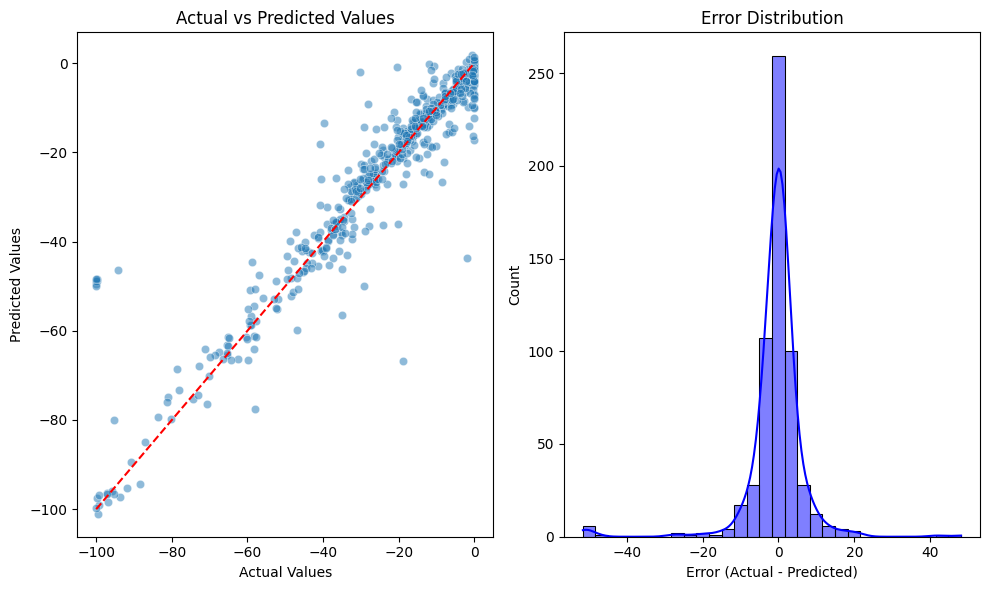

In [13]:
model,y_test,y_pred,X_train = train_xgboost_regression_model(data)
plot_regression_results(y_test,y_pred)

In [ ]:
# 결과 확인

# ecu: 0.94 (r^2)

In [15]:
def save_model_to_pickle(model, file_path):
    """
    모델을 피클 파일로 저장하는 함수.

    Args:
    - model: 저장할 모델 객체 (예: 학습된 모델)
    - file_path: 저장할 피클 파일의 경로
    """
    with open(file_path, 'wb') as file:
        pickle.dump(model, file)
    print(f"모델이 {file_path}에 성공적으로 저장되었습니다.")
    
# 6. 모델 저장 
health_model.save_model_to_pickle(model, r"C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\ecu_model")

모델이 C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\ecu_model에 성공적으로 저장되었습니다.
